__EN3160 Assignment 1 on Intensity Transformations and Neighborhood
Filtering__

### (1). Intensity transformation

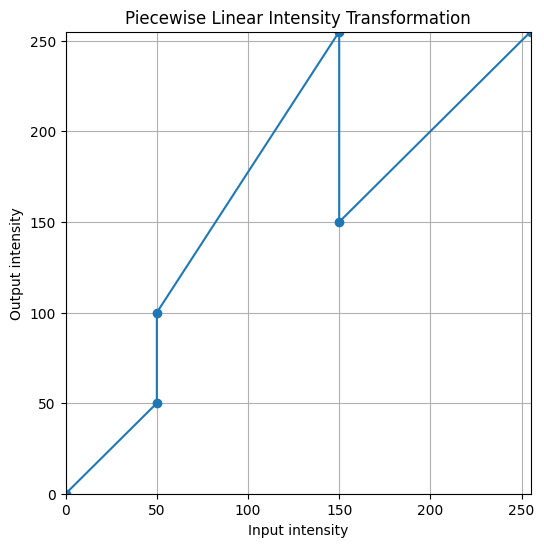

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

##piecewise linear intensity transformation
breakpoints = np.array([
    [0, 0],
    [50, 50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255]
], dtype=np.float32)

x = breakpoints[:, 0]
y = breakpoints[:, 1]

plt.figure(figsize=(6, 6))

plt.plot(x, y, marker='o')

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Linear Intensity Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.grid(True)
plt.show()

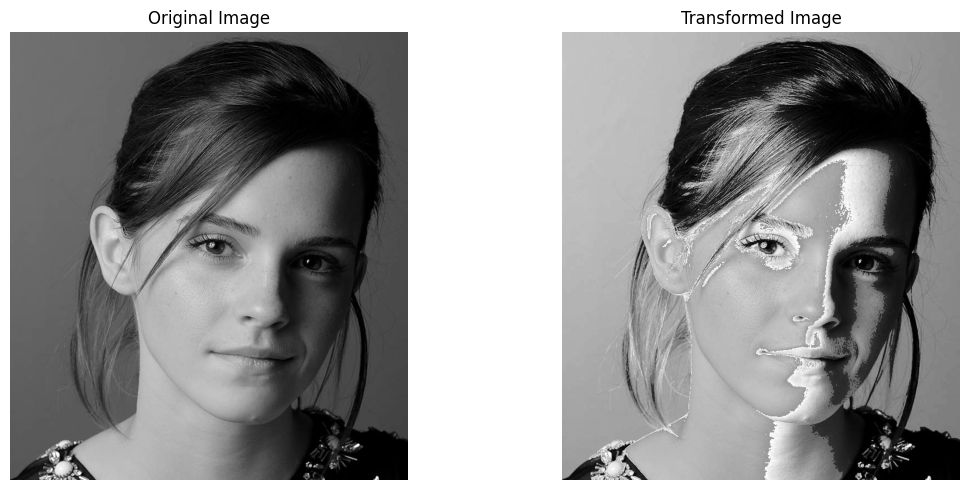

In [3]:
## define the intensity transformation function
def intensity_transformation(im,breakpoints):
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]
    im_transformed = np.interp(im.flatten(), x, y)
    return im_transformed.reshape(im.shape).astype(np.uint8)

## read the image
im = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q1.jpeg",cv2.IMREAD_GRAYSCALE)

## apply the intensity transformation
transformed = intensity_transformation(im, breakpoints)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(im, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transformed, cmap="gray")
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

### (2).Brain image enhancement

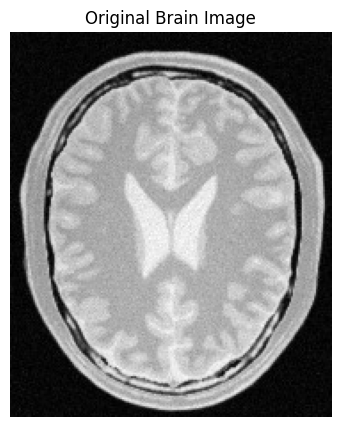

In [4]:
brain = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q2.jpeg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6, 5))
plt.imshow(brain, cmap="gray")
plt.title("Original Brain Image")
plt.axis("off")
plt.show()

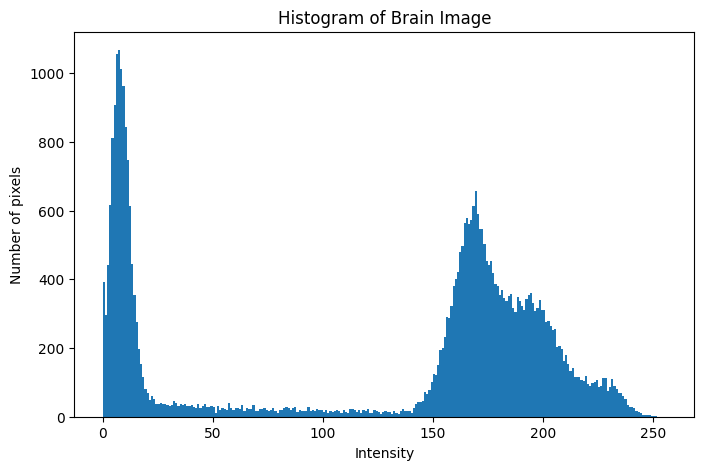

In [5]:
##get the distribution of pixel intensities in the brain image
plt.figure(figsize=(8, 5))

plt.hist(brain.ravel(), bins=256, range=(0, 256))

plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Histogram of Brain Image")

plt.show()

according to the histogram most of the white matter approximatelty in the range of 150 - 220 intensities. So that we should define new breakpoints to enhance the white matters.

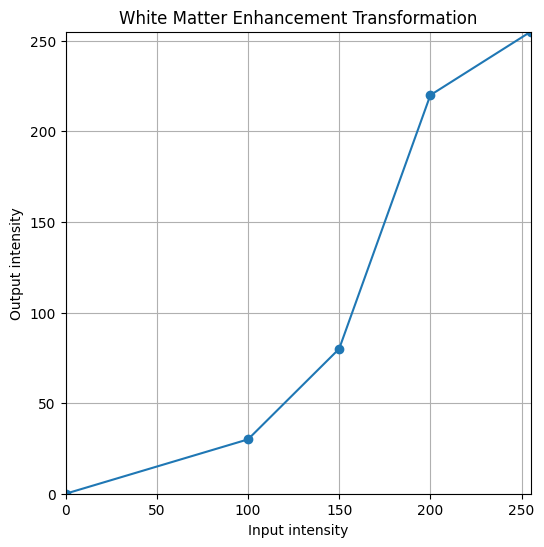

In [6]:
## define the breakpoints for the piecewise linear transformation
white_breakpoints = np.array([
    [0, 0],
    [100, 30],
    [150, 80],
    [200, 220],
    [255, 255]
], dtype=np.float32)
plt.figure(figsize=(6, 6))

plt.plot(
    white_breakpoints[:, 0],
    white_breakpoints[:, 1],
    marker='o'
)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("White Matter Enhancement Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)

plt.show()



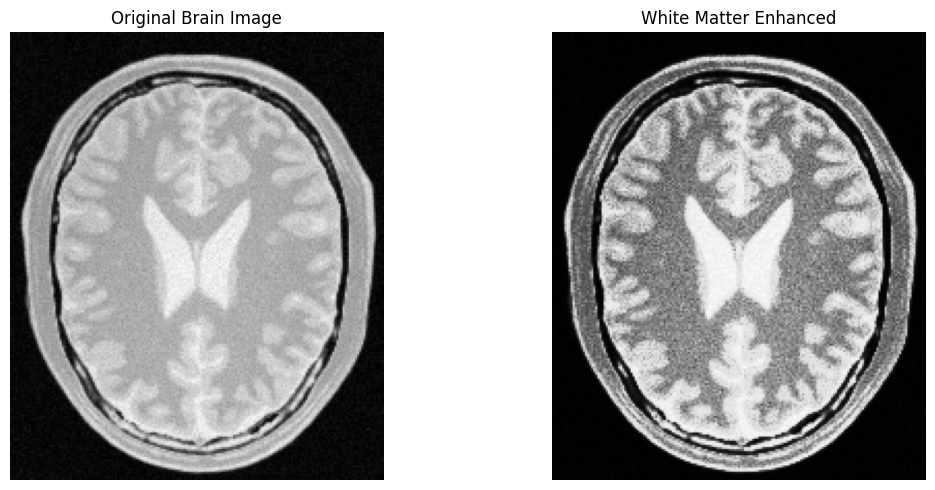

In [7]:
white_enhanced = intensity_transformation(brain,white_breakpoints)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(brain, cmap="gray")
plt.title("Original Brain Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(white_enhanced, cmap="gray")
plt.title("White Matter Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

according to the histogram most of the gray matters in the ranges of approximately 80 - 150 intensities.

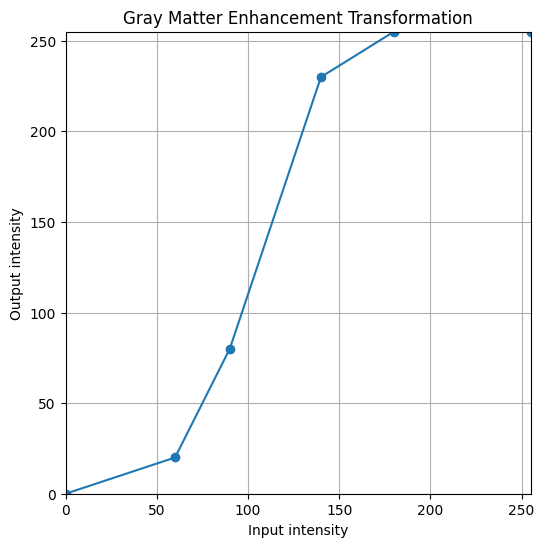

In [8]:
gray_breakpoints = np.array([
    [0, 0],
    [60, 20],
    [90, 80],
    [140, 230],
    [180, 255],
    [255, 255]
], dtype=np.float32)

plt.figure(figsize=(6, 6))

plt.plot(
    gray_breakpoints[:, 0],
    gray_breakpoints[:, 1],
    marker='o'
)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Gray Matter Enhancement Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)

plt.show()

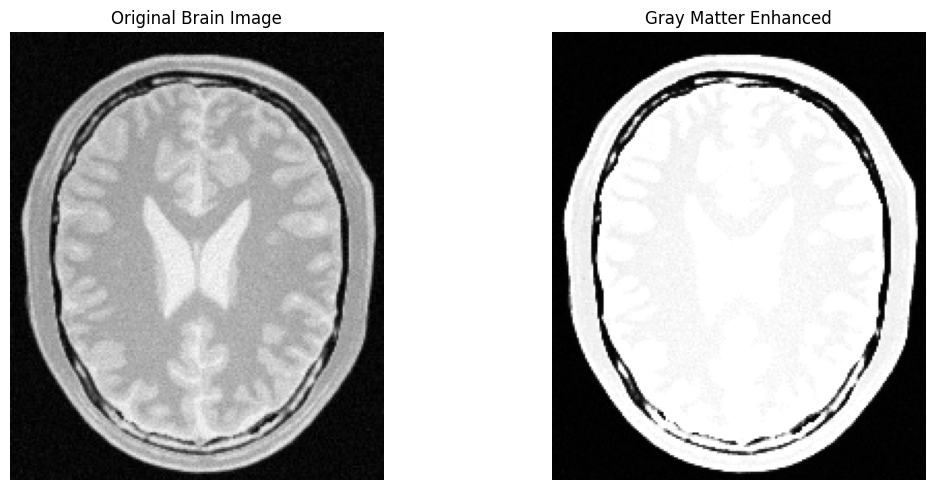

In [9]:
gray_enhanced = intensity_transformation(brain,gray_breakpoints)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(brain, cmap="gray")
plt.title("Original Brain Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_enhanced, cmap="gray")
plt.title("Gray Matter Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

### (3).Gamma correction

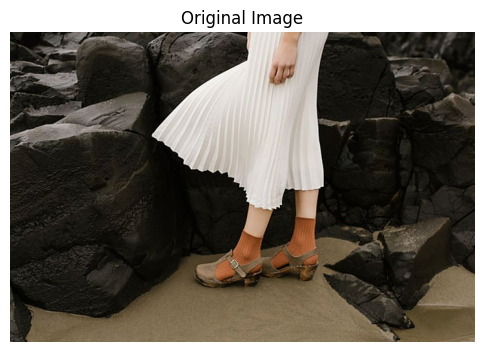

In [10]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q3.jpeg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 5))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

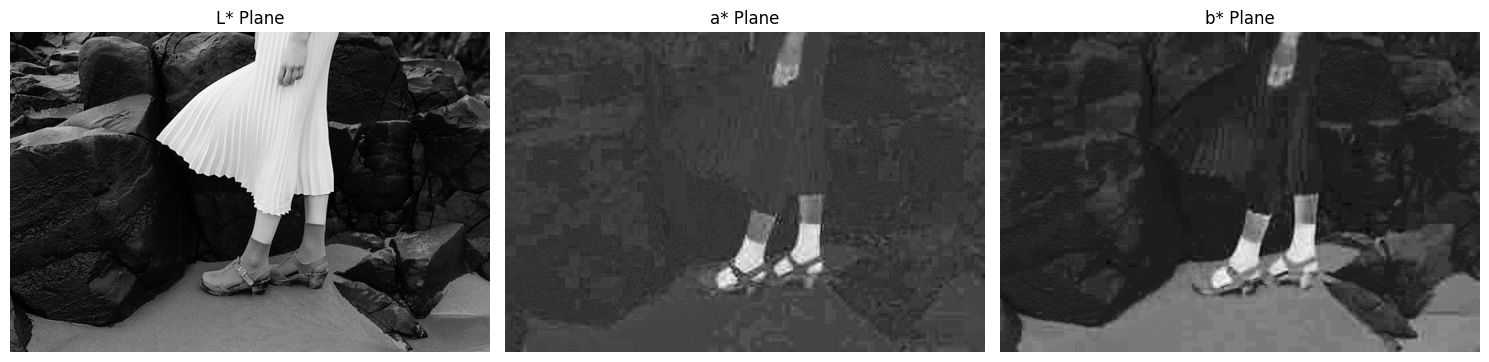

In [11]:
## convert the image to LAB color space and split the channels
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

## visualize the L*, a*, and b* planes
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(L, cmap="gray")
plt.title("L* Plane")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(a, cmap="gray")
plt.title("a* Plane")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(b, cmap="gray")
plt.title("b* Plane")
plt.axis("off")

plt.tight_layout()
plt.show()

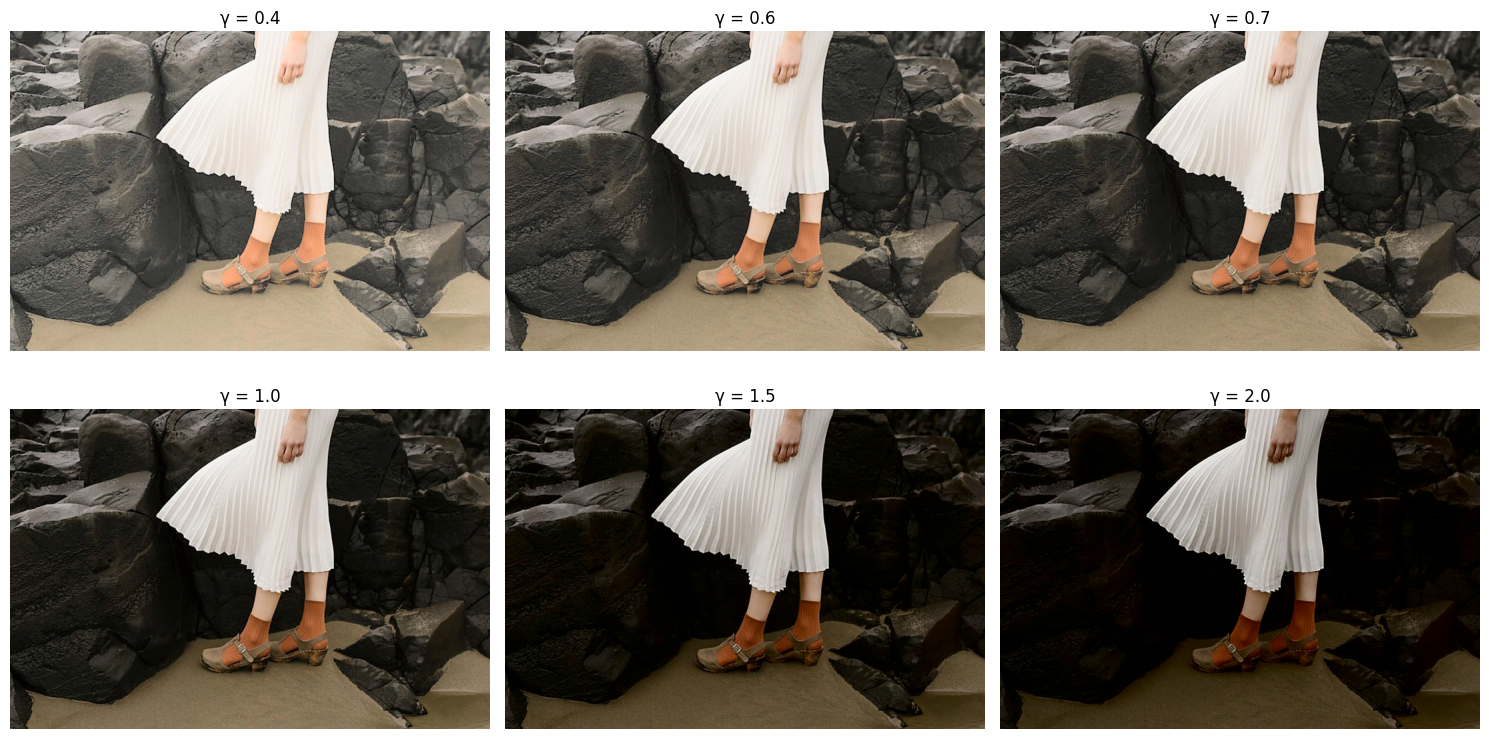

In [12]:
gammas = [0.4, 0.6,0.7, 1.0, 1.5, 2.0]
plt.figure(figsize=(15, 8))

for i, gamma in enumerate(gammas):

    L_norm = L.astype(np.float32) / 255.0
    L_gamma = np.power(L_norm, gamma)
    L_gamma = np.clip(L_gamma * 255,0,255).astype(np.uint8)

    lab_gamma = cv2.merge([L_gamma, a, b])

    corrected = cv2.cvtColor(lab_gamma,cv2.COLOR_LAB2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(corrected)
    plt.title(f"γ = {gamma}")
    plt.axis("off")

plt.tight_layout()
plt.show()

choose the gamma = 0.7

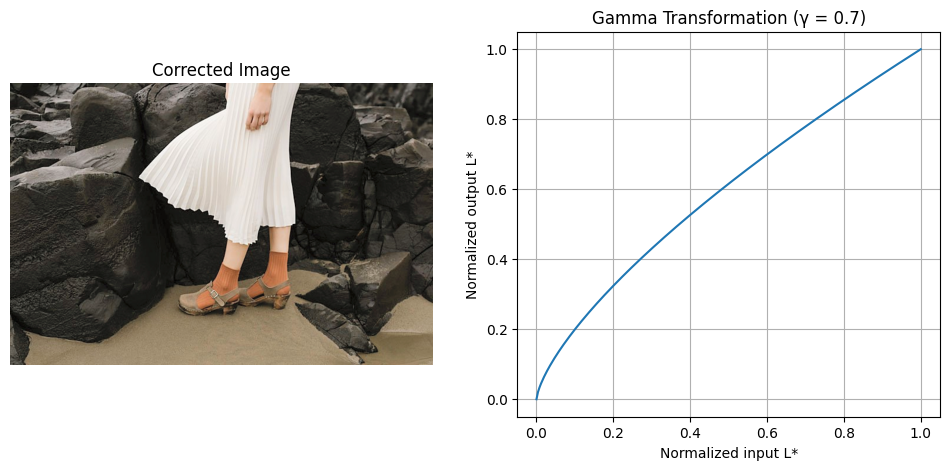

In [13]:
gamma = 0.7

L_norm = L.astype(np.float32) / 255.0
L_gamma = np.power(L_norm, gamma)
L_gamma = np.clip(L_gamma * 255,0,255).astype(np.uint8)

lab_gamma = cv2.merge([L_gamma, a, b])
corrected_image = cv2.cvtColor(lab_gamma,cv2.COLOR_LAB2RGB)

r = np.linspace(0, 1, 256)
s = r ** gamma

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(corrected_image)
plt.title("Corrected Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.plot(r, s)

plt.xlabel("Normalized input L*")
plt.ylabel("Normalized output L*")
plt.title(f"Gamma Transformation (γ = {gamma})")

plt.grid(True)
plt.show()



Since gamma < 1 the curve should be above the diagonal, showing that the output lightness is increased.

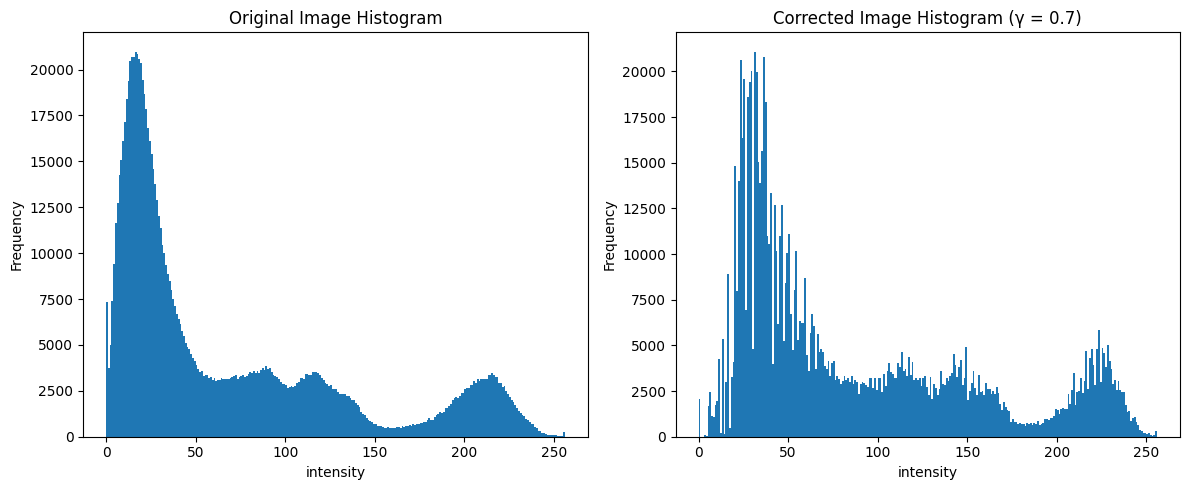

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.hist(img_rgb.ravel(),bins=256,range=(0, 256))

plt.xlabel("intensity")
plt.ylabel("Frequency")
plt.title("Original Image Histogram")


plt.subplot(1, 2, 2)

plt.hist(corrected_image.ravel(),bins=256,range=(0, 256))

plt.xlabel("intensity")
plt.ylabel("Frequency")
plt.title(f"Corrected Image Histogram (γ = {gamma})")

plt.tight_layout()
plt.show()

### (4). Vibrance Enhancement

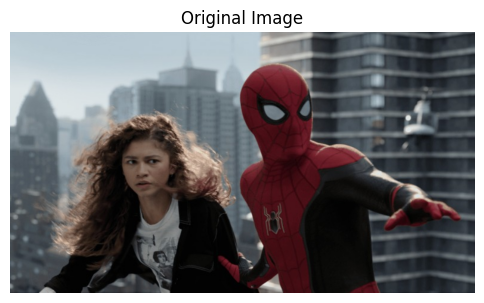

In [15]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q4.jpeg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,5))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

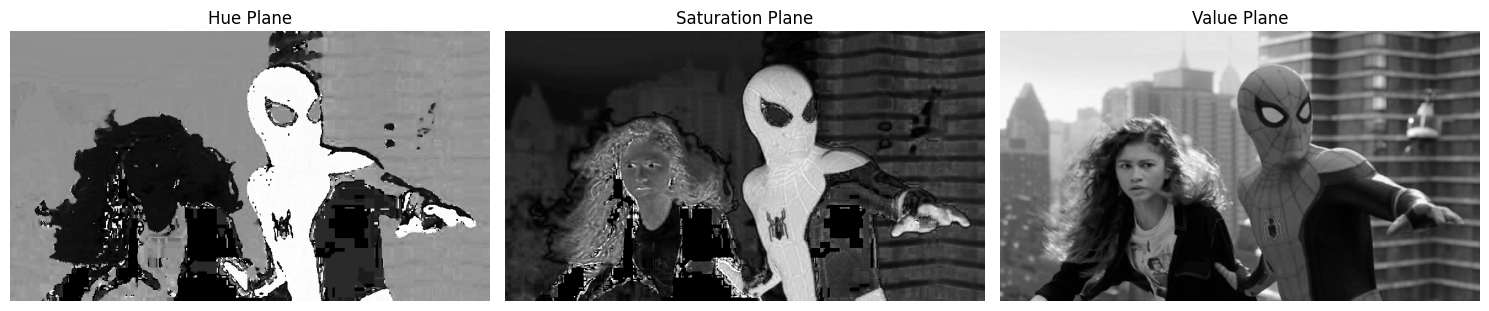

In [16]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue Plane")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation Plane")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value Plane")
plt.axis("off")

plt.tight_layout()
plt.show()

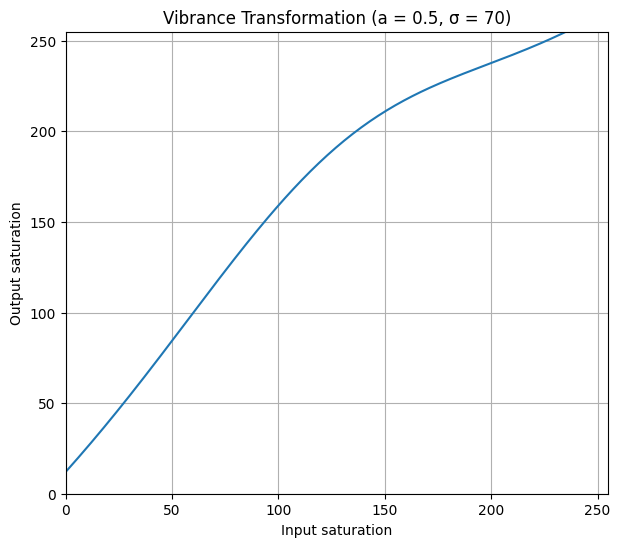

In [ ]:
### define the parameters for the transformation
sigma = 70
a = 0.5
## x represents the original saturation intensity.
x = np.arange(256)

transformation = x + a * 128 * np.exp(
    -((x - 128) ** 2) / (2 * sigma ** 2)
)

transformation = np.clip(transformation, 0, 255)

plt.figure(figsize=(7, 6))

plt.plot(x, transformation)

plt.xlabel("Input saturation")
plt.ylabel("Output saturation")
plt.title(f"Vibrance Transformation (a = {a}, σ = {sigma})")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)

plt.show()

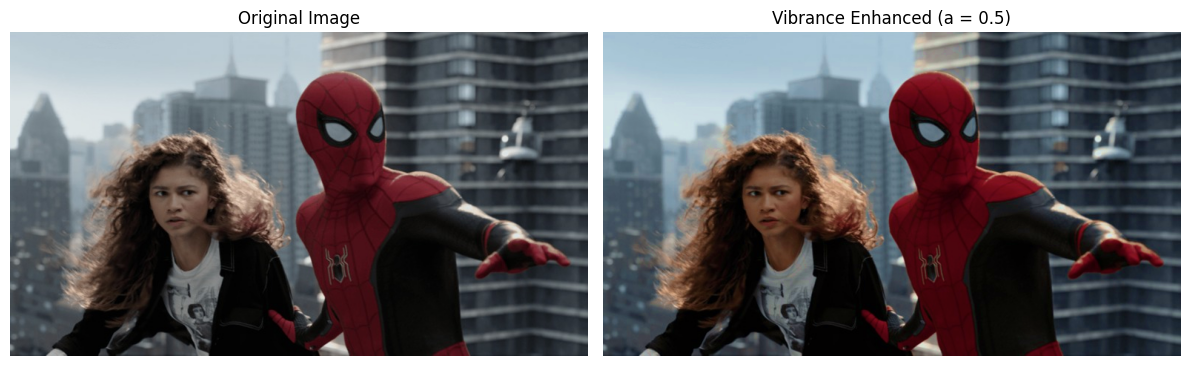

In [ ]:
lookup_table = np.clip(x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)),0,255).astype(np.uint8)
S_enhanced = lookup_table[S]
## merge the enhanced saturation channel with the original hue and value channels
hsv_enhanced = cv2.merge([H,S_enhanced,V])

enhanced_bgr = cv2.cvtColor(hsv_enhanced,cv2.COLOR_HSV2BGR)
enhanced_rgb = cv2.cvtColor(enhanced_bgr,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced_rgb)
plt.title(f"Vibrance Enhanced (a = {a})")
plt.axis("off")

plt.tight_layout()
plt.show()

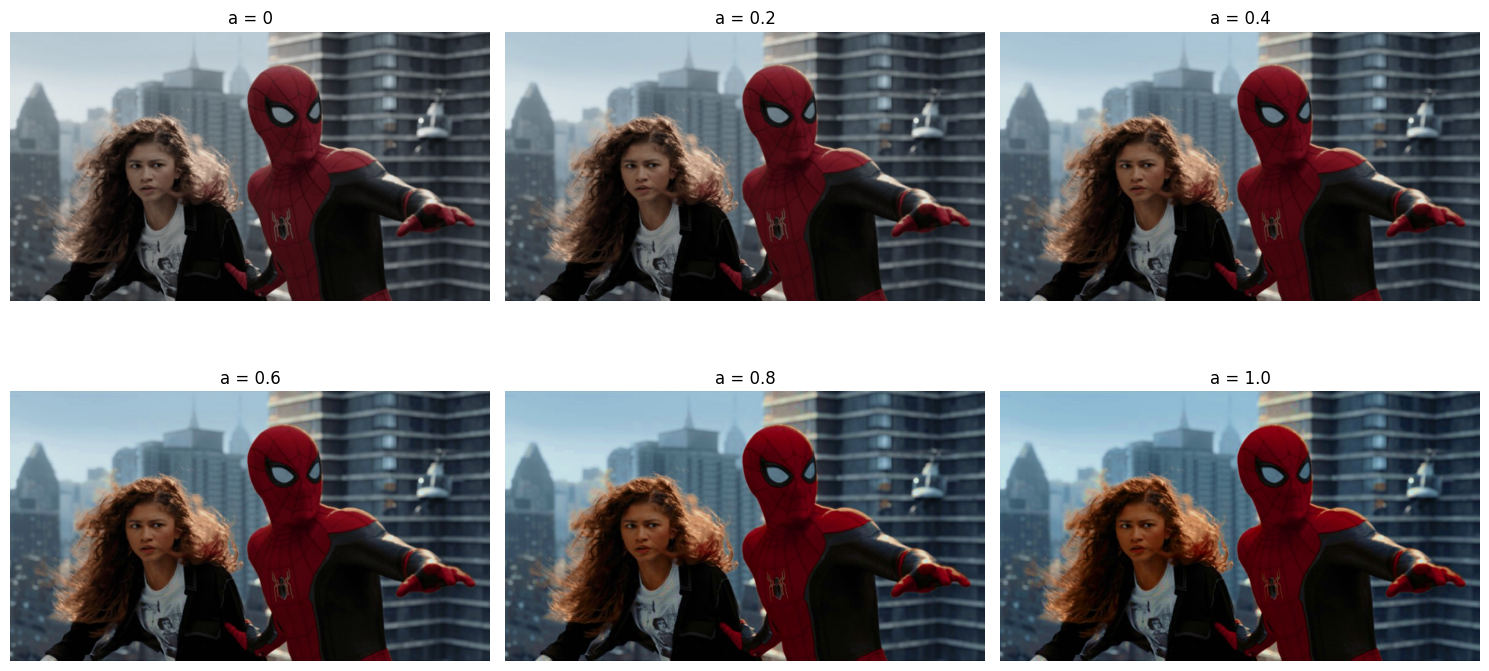

In [25]:
a_values = [0,0.2, 0.4, 0.6, 0.8, 1.0]

plt.figure(figsize=(15, 8))

for i, a in enumerate(a_values):

    lookup_table = np.clip(
        x + a * 128 * np.exp(
            -((x - 128) ** 2) / (2 * sigma ** 2)
        ),
        0,
        255
    ).astype(np.uint8)

    S_enhanced = lookup_table[S]

    hsv_enhanced = cv2.merge([
        H,
        S_enhanced,
        V
    ])

    enhanced_bgr = cv2.cvtColor(
        hsv_enhanced,
        cv2.COLOR_HSV2BGR
    )

    enhanced_rgb = cv2.cvtColor(
        enhanced_bgr,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(enhanced_rgb)
    plt.title(f"a = {a}")
    plt.axis("off")

plt.tight_layout()
plt.show()